<a href="https://colab.research.google.com/github/epibeat/resume/blob/main/Mini_Health_Data_Warehouse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import json
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
patients = pd.read_csv("patients.csv")
encounters = pd.read_csv("encounters.csv")
conditions = pd.read_csv("conditions.csv")
observations = pd.read_csv("observations.csv")

print("Patients shape:", patients.shape)
print("Encounters shape:", encounters.shape)
print("Conditions shape:", conditions.shape)
print("Observations shape:", observations.shape)

Patients shape: (1163, 25)
Encounters shape: (61459, 15)
Conditions shape: (38094, 6)
Observations shape: (458843, 9)


In [ ]:
patients.head(20).to_json("patients_sample.json", orient="records", indent=2)

with open("patients_sample.json", "r") as f:
    patient_json = json.load(f)

json_df = pd.DataFrame(patient_json)

print(json_df.head())

                                     Id   BIRTHDATE DEATHDATE          SSN  \
0  b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85  2019-02-17      None  999-65-3251   
1  c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8  2005-07-04      None  999-49-3323   
2  339144f8-50e1-633e-a013-f361391c4cff  1998-05-11      None  999-10-8743   
3  d488232e-bf14-4bed-08c0-a82f34b6a197  2003-01-28      None  999-56-6057   
4  217f95a3-4e10-bd5d-fb67-0cfb5e8ba075  1993-12-23      None  999-91-4320   

     DRIVERS    PASSPORT PREFIX       FIRST            LAST SUFFIX  ...  \
0       None        None   None    Damon455      Langosh790   None  ...   
1  S99941126        None   None       Thi53       Wunsch504   None  ...   
2  S99996708  X75063318X    Mr.      Chi716  Greenfelder433   None  ...   
3  S99929424        None    Ms.  Phillis443       Walter473   None  ...   
4  S99991143  X44132498X    Mr.  Jerrold404       Herzog843   None  ...   

                         BIRTHPLACE                           ADDRESS  \
0  Midd

In [ ]:
html_table = patients.head(10).to_html(index=False)

with open("patients_table.html", "w") as f:
    f.write(html_table)

html_df = pd.read_html("patients_table.html")[0]

print(html_df.head())

                                     Id   BIRTHDATE  DEATHDATE          SSN  \
0  b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85  2019-02-17        NaN  999-65-3251   
1  c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8  2005-07-04        NaN  999-49-3323   
2  339144f8-50e1-633e-a013-f361391c4cff  1998-05-11        NaN  999-10-8743   
3  d488232e-bf14-4bed-08c0-a82f34b6a197  2003-01-28        NaN  999-56-6057   
4  217f95a3-4e10-bd5d-fb67-0cfb5e8ba075  1993-12-23        NaN  999-91-4320   

     DRIVERS    PASSPORT PREFIX       FIRST            LAST  SUFFIX  ...  \
0        NaN         NaN    NaN    Damon455      Langosh790     NaN  ...   
1  S99941126         NaN    NaN       Thi53       Wunsch504     NaN  ...   
2  S99996708  X75063318X    Mr.      Chi716  Greenfelder433     NaN  ...   
3  S99929424         NaN    Ms.  Phillis443       Walter473     NaN  ...   
4  S99991143  X44132498X    Mr.  Jerrold404       Herzog843     NaN  ...   

                       BIRTHPLACE                           ADDRESS 

In [ ]:
print(patients.columns)
print(encounters.columns)

patients.head()

Index(['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX',
       'FIRST', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY',
       'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'ZIP',
       'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE'],
      dtype='object')
Index(['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER', 'PAYER',
       'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST',
       'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE',
       'REASONDESCRIPTION'],
      dtype='object')


,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,2019-02-17,NaN,999-65-3251,NaN,NaN,NaN,Damon455,Langosh790,NaN,...,Middleborough Massachusetts US,620 Lynch Tunnel Apt 0,Springfield,Massachusetts,Hampden County,1104.0,42.080389,-72.480431,9039.1645,7964.1255
1,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,2005-07-04,NaN,999-49-3323,S99941126,NaN,NaN,Thi53,Wunsch504,NaN,...,Danvers Massachusetts US,972 Tillman Branch Suite 48,Bellingham,Massachusetts,Norfolk County,NaN,42.035213,-71.482519,402723.4150,14064.1350
2,339144f8-50e1-633e-a013-f361391c4cff,1998-05-11,NaN,999-10-8743,S99996708,X75063318X,Mr.,Chi716,Greenfelder433,NaN,...,Athens Athens Prefecture GR,1060 Bernhard Crossroad Suite 15,Boston,Massachusetts,Suffolk County,2131.0,42.292557,-71.061160,571935.8725,787.5375
3,d488232e-bf14-4bed-08c0-a82f34b6a197,2003-01-28,NaN,999-56-6057,S99929424,NaN,Ms.,Phillis443,Walter473,NaN,...,Boston Massachusetts US,677 Ritchie Terrace,Hingham,Massachusetts,Plymouth County,2043.0,42.200491,-70.916076,582557.8030,104782.2070
4,217f95a3-4e10-bd5d-fb67-0cfb5e8ba075,1993-12-23,NaN,999-91-4320,S99991143,X44132498X,Mr.,Jerrold404,Herzog843,NaN,...,Boston Massachusetts US,276 Bernier Branch,Revere,Massachusetts,Suffolk County,NaN,42.381875,-70.999286,475826.8550,18067.0950


In [ ]:
patients.columns = patients.columns.str.lower().str.strip()
encounters.columns = encounters.columns.str.lower().str.strip()
conditions.columns = conditions.columns.str.lower().str.strip()
observations.columns = observations.columns.str.lower().str.strip()

print("Columns standardized")

Columns standardized


In [ ]:
patients["birthdate"] = pd.to_datetime(patients["birthdate"], errors="coerce")

encounters["start"] = pd.to_datetime(encounters["start"], errors="coerce")
encounters["stop"] = pd.to_datetime(encounters["stop"], errors="coerce")

In [ ]:
print("Missing Values - Patients")
print(patients.isnull().sum())

print("Missing Values - Encounters")
print(encounters.isnull().sum())

Missing Values - Patients
id                        0
birthdate                 0
deathdate              1000
ssn                       0
drivers                 215
passport                276
prefix                  245
first                     0
last                      0
suffix                 1147
maiden                  832
marital                 384
race                      0
ethnicity                 0
gender                    0
birthplace                0
address                   0
city                      0
state                     0
county                    0
zip                     545
lat                       0
lon                       0
healthcare_expenses       0
healthcare_coverage       0
dtype: int64
Missing Values - Encounters
id                         0
start                      0
stop                       0
patient                    0
organization               0
provider                   0
payer                      0
encounterclass             0
c

In [ ]:
patients.fillna("Unknown", inplace=True)
encounters.fillna("Unknown", inplace=True)

/tmp/ipykernel_14216/4152106068.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  patients.fillna("Unknown", inplace=True)
/tmp/ipykernel_14216/4152106068.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  encounters.fillna("Unknown", inplace=True)


In [ ]:
patients_before = patients.shape[0]
patients = patients.drop_duplicates()
patients_after = patients.shape[0]

print("Duplicates removed:", patients_before - patients_after)

Duplicates removed: 0


In [ ]:
patients["birthdate"] = pd.to_datetime(patients["birthdate"], errors="coerce")

In [ ]:
today = pd.Timestamp.today()

patients["age"] = ((today - patients["birthdate"]).dt.days / 365.25).round().astype("Int64")

patients[["birthdate", "age"]].head()

,birthdate,age
0,2019-02-17,7
1,2005-07-04,21
2,1998-05-11,28
3,2003-01-28,23
4,1993-12-23,32


In [ ]:
text_cols = patients.select_dtypes(include="object").columns
patients[text_cols] = patients[text_cols].fillna("Unknown")

In [ ]:
patients[["birthdate", "age"]].head()
print(patients["age"].dtype)

Int64


In [ ]:
merged = encounters.merge(
    patients,
    left_on="patient",
    right_on="id",
    how="left"
)

print(merged.shape)
merged.head()

(61459, 41)


,id_x,start,stop,patient,organization,provider,payer,encounterclass,code,description,...,address,city,state,county,zip,lat,lon,healthcare_expenses,healthcare_coverage,age
0,748f8357-6cc7-551d-f31a-32fa2cf84126,2019-02-17 05:07:38+00:00,2019-02-17 05:22:38+00:00,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),...,620 Lynch Tunnel Apt 0,Springfield,Massachusetts,Hampden County,1104.0,42.080389,-72.480431,9039.1645,7964.1255,7
1,5a4735ae-423f-6563-28ab-b3d11b49b2d4,2019-03-24 05:07:38+00:00,2019-03-24 05:22:38+00:00,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),...,620 Lynch Tunnel Apt 0,Springfield,Massachusetts,Hampden County,1104.0,42.080389,-72.480431,9039.1645,7964.1255,7
2,0bee1ce6-3e2c-5506-f71c-a7ba8f64a3d3,2019-05-26 05:07:38+00:00,2019-05-26 05:22:38+00:00,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),...,620 Lynch Tunnel Apt 0,Springfield,Massachusetts,Hampden County,1104.0,42.080389,-72.480431,9039.1645,7964.1255,7
3,6e93bcf9-45a4-8528-0120-1c1eaa930faf,2019-07-28 05:07:38+00:00,2019-07-28 05:22:38+00:00,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),...,620 Lynch Tunnel Apt 0,Springfield,Massachusetts,Hampden County,1104.0,42.080389,-72.480431,9039.1645,7964.1255,7
4,8b6787c3-4316-a0cb-899d-4746525c319f,2019-10-27 05:07:38+00:00,2019-10-27 05:22:38+00:00,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),...,620 Lynch Tunnel Apt 0,Springfield,Massachusetts,Hampden County,1104.0,42.080389,-72.480431,9039.1645,7964.1255,7


In [ ]:
visit_counts = merged.groupby("patient").size().reset_index(name="total_visits")

visit_counts.head()

,patient,total_visits
0,00126cb9-8460-4747-e302-c3609684531e,60
1,00209bf2-8e4d-06d1-82a4-daad02f25829,76
2,00ae3b00-9500-efc1-2758-a93d3f77e650,40
3,00c9ca99-6b9f-add4-8759-f7dfee6ea1a4,47
4,0142b69f-57f0-9a08-4e2d-65a2b77fdea7,41


In [ ]:
patients = patients.merge(
    visit_counts,
    left_on="id",
    right_on="patient",
    how="left"
)

patients["total_visits"] = patients["total_visits"].fillna(0)
patients.head()

,id,birthdate,deathdate,ssn,drivers,passport,prefix,first,last,suffix,...,state,county,zip,lat,lon,healthcare_expenses,healthcare_coverage,age,patient,total_visits
0,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,2019-02-17,Unknown,999-65-3251,Unknown,Unknown,Unknown,Damon455,Langosh790,Unknown,...,Massachusetts,Hampden County,1104.0,42.080389,-72.480431,9039.1645,7964.1255,7,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,12
1,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,2005-07-04,Unknown,999-49-3323,S99941126,Unknown,Unknown,Thi53,Wunsch504,Unknown,...,Massachusetts,Norfolk County,Unknown,42.035213,-71.482519,402723.4150,14064.1350,21,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,20
2,339144f8-50e1-633e-a013-f361391c4cff,1998-05-11,Unknown,999-10-8743,S99996708,X75063318X,Mr.,Chi716,Greenfelder433,Unknown,...,Massachusetts,Suffolk County,2131.0,42.292557,-71.061160,571935.8725,787.5375,28,339144f8-50e1-633e-a013-f361391c4cff,19
3,d488232e-bf14-4bed-08c0-a82f34b6a197,2003-01-28,Unknown,999-56-6057,S99929424,Unknown,Ms.,Phillis443,Walter473,Unknown,...,Massachusetts,Plymouth County,2043.0,42.200491,-70.916076,582557.8030,104782.2070,23,d488232e-bf14-4bed-08c0-a82f34b6a197,31
4,217f95a3-4e10-bd5d-fb67-0cfb5e8ba075,1993-12-23,Unknown,999-91-4320,S99991143,X44132498X,Mr.,Jerrold404,Herzog843,Unknown,...,Massachusetts,Suffolk County,Unknown,42.381875,-70.999286,475826.8550,18067.0950,32,217f95a3-4e10-bd5d-fb67-0cfb5e8ba075,10


In [ ]:
pivot_age_gender = pd.pivot_table(
    patients,
    values="total_visits",
    index="gender",
    aggfunc="mean"
)

print(pivot_age_gender)

        total_visits
gender              
F          57.683442
M          47.396709


In [ ]:
import sqlite3

conn = sqlite3.connect("hospital_warehouse.db")

In [ ]:
patients.to_sql("patients", conn, if_exists="replace", index=False)
encounters.to_sql("encounters", conn, if_exists="replace", index=False)
conditions.to_sql("conditions", conn, if_exists="replace", index=False)

print("Tables loaded successfully")

Tables loaded successfully


In [ ]:
query = """
SELECT gender, COUNT(*) as patients_count
FROM patients
GROUP BY gender
"""

pd.read_sql(query, conn)

,gender,patients_count
0,F,616
1,M,547


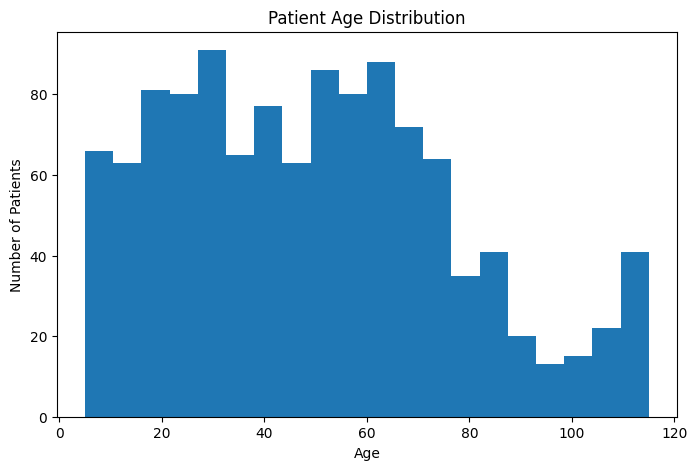

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(patients["age"].dropna(), bins=20)
plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.savefig("figures_age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

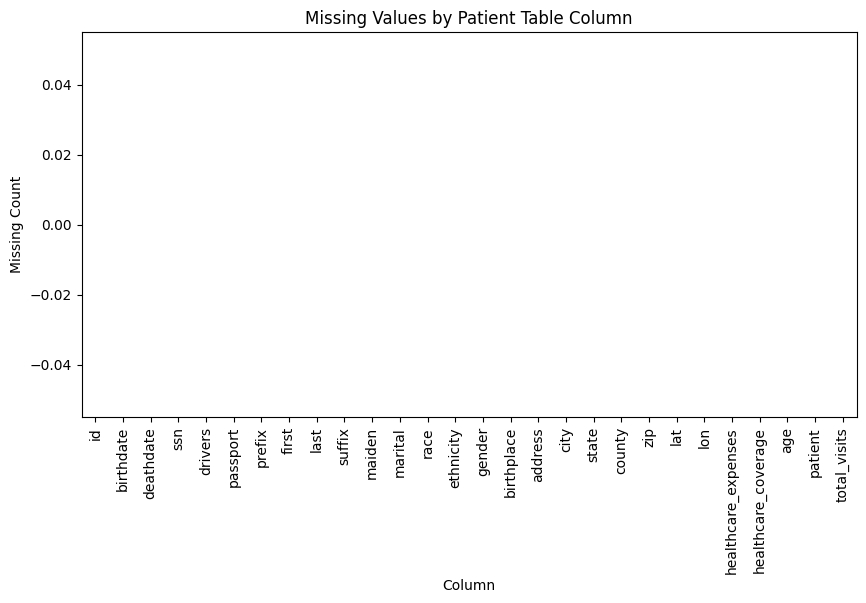

In [ ]:
missing_counts = patients.isnull().sum()

plt.figure(figsize=(10,5))
missing_counts.plot(kind="bar")
plt.title("Missing Values by Patient Table Column")
plt.xlabel("Column")
plt.ylabel("Missing Count")
plt.xticks(rotation=90)
plt.savefig("figures_missingness.png", dpi=300, bbox_inches="tight")
plt.show()

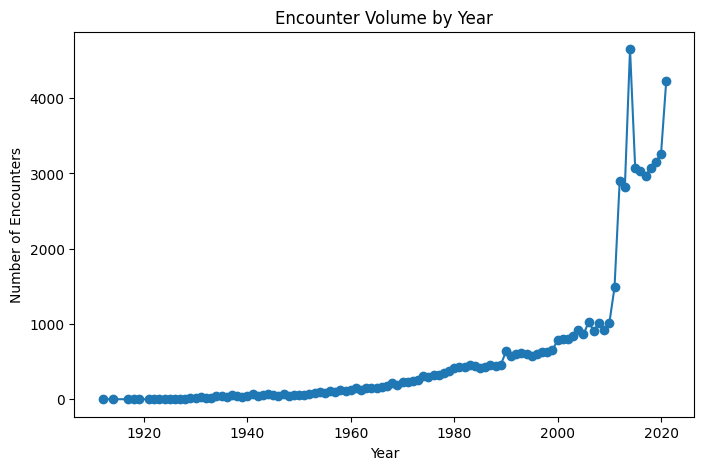

In [ ]:
encounters["year"] = pd.to_datetime(encounters["start"], errors="coerce").dt.year

encounter_trends = encounters.groupby("year").size()

plt.figure(figsize=(8,5))
encounter_trends.plot(kind="line", marker="o")
plt.title("Encounter Volume by Year")
plt.xlabel("Year")
plt.ylabel("Number of Encounters")
plt.savefig("figures_encounter_trends.png", dpi=300, bbox_inches="tight")
plt.show()

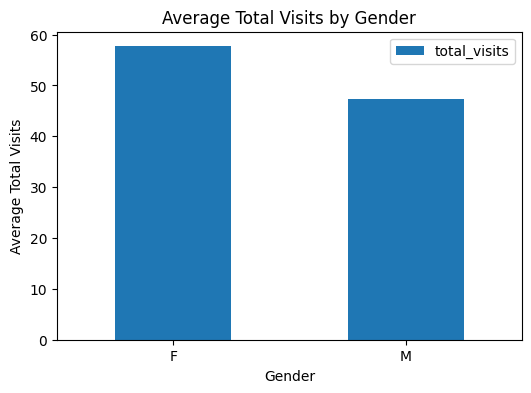

In [ ]:
pivot_age_gender.plot(kind="bar", figsize=(6,4))
plt.title("Average Total Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Total Visits")
plt.xticks(rotation=0)
plt.savefig("figures_avg_visits_gender.png", dpi=300, bbox_inches="tight")
plt.show()

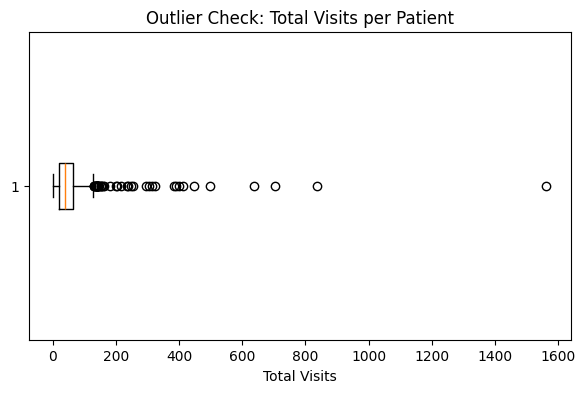

In [ ]:
plt.figure(figsize=(7,4))
plt.boxplot(patients["total_visits"].dropna(), vert=False)
plt.title("Outlier Check: Total Visits per Patient")
plt.xlabel("Total Visits")
plt.savefig("figures_visit_outliers.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
error_log = []

In [ ]:
def check_duplicate_ids(df):
    dupes = df[df["id"].duplicated()]

    if len(dupes) > 0:
        error_log.append(f"Duplicate patient IDs found: {len(dupes)}")

    return dupes

duplicate_ids = check_duplicate_ids(patients)
print("Duplicate IDs:", len(duplicate_ids))

Duplicate IDs: 0


In [ ]:
def check_invalid_age(df):
    bad = df[(df["age"] < 0) | (df["age"] > 110)]

    if len(bad) > 0:
        error_log.append(f"Invalid ages found: {len(bad)}")

    return bad

bad_age = check_invalid_age(patients)
print("Invalid ages:", len(bad_age))

Invalid ages: 35


In [ ]:
def check_missing_keys(df):
    missing = df[df["id"].isnull()]

    if len(missing) > 0:
        error_log.append(f"Missing IDs found: {len(missing)}")

    return missing

missing_ids = check_missing_keys(patients)
print("Missing IDs:", len(missing_ids))

Missing IDs: 0


In [ ]:
try:
    patients["age_test"] = patients["age"] / 0
except Exception as e:
    error_log.append(f"Calculation error: {str(e)}")
    print("Handled error successfully")

In [ ]:
with open("pipeline_log.txt", "w") as f:
    for item in error_log:
        f.write(item + "\n")

print("Log file created")

Log file created


In [ ]:
print(error_log)

['Invalid ages found: 35']
